Model Accuracy: 100.0 %
Enter study hours: 7
Predicted Result: Pass
Pass Probability: 85.18 %


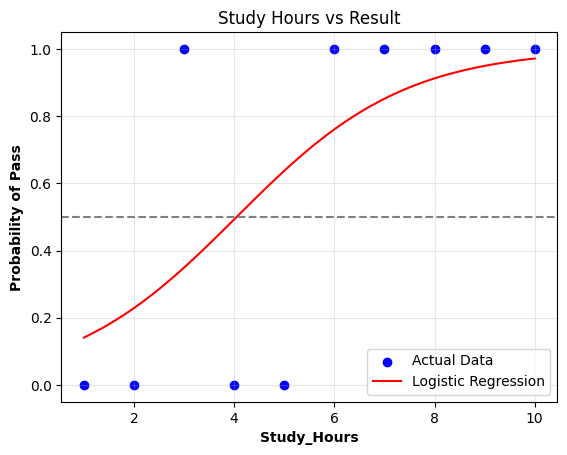

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Test model
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# User input
hours = float(input("Enter study hours: "))

prediction = model.predict([[hours]])
probability = model.predict_proba([[hours]])

if prediction[0] == 1:
    print("Predicted Result: Pass")
else:
    print("Predicted Result: Fail")

print("Pass Probability:", round(probability[0][1] * 100, 2), "%")


# -------------------------------
# LOGISTIC_REGRESSION PLOT
# -------------------------------

# Create values for smooth curve
hours_range = np.linspace(1, 10, 100).reshape(-1, 1)

# Get probability of passing
pass_probability = model.predict_proba(hours_range)[:, 1]

# Plot actual data
plt.scatter(X, y, color="blue", label="Actual Data")

# Plot logistic regression curve
plt.plot(
    hours_range,
    pass_probability,
    color="red",
    label="Logistic Regression"
)

# Decision threshold
plt.axhline(0.5, color="gray", linestyle="--")

# Labels
plt.xlabel(
    "Study_Hours",
    fontweight="bold"
)
plt.ylabel(
    "Probability of Pass",
    fontweight="bold")
plt.title("Study Hours vs Result")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()